In [1]:
#First the necessary libraries are imported
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

#Now the data is downloaded from yahoofinance. I have chosen 5 years of data from 2020 to now. 
data = yf.download("MSFT", start = "2020-01-01", end = "2026-03-06", progress = False, multi_level_index = False)
#progress = False eliminates the download progress bar and multi_level_index = False to eliminate the multi-index columns. With this multiindex the next kernell would only work the first time it was ran.
display(data.head())
display(data.tail())
print("We can see that the data has been extracted correctly.")

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,152.158401,152.262607,149.989047,150.415338,22622100
2020-01-03,150.263779,151.523715,149.733282,149.979594,21116200
2020-01-06,150.652176,150.718495,148.264927,148.804906,20813700
2020-01-07,149.278549,151.258443,149.032251,150.926890,21634100
2020-01-08,151.656326,152.328929,149.629064,150.557433,27746500


,Close,High,Low,Open,Volume
Date,,,,,
2026-02-27,392.739990,396.820007,389.880005,390.880005,51367200
2026-03-02,398.549988,401.190002,390.630005,392.859985,35474900
2026-03-03,403.929993,406.700012,392.670013,393.140015,38199200
2026-03-04,405.200012,411.029999,400.309998,401.269989,35808000
2026-03-05,410.679993,411.609985,404.399994,404.420013,39001300


We can see that the data has been extracted correctly.


In [2]:
#Now the daily returns are calculated, we are more interested in the log returns.
data["simple_returns"] = data["Close"].pct_change()
data["Log_Returns"] = np.log(data["Close"] / data["Close"].shift(1))
data.head()

,Close,High,Low,Open,Volume,simple_returns,Log_Returns
Date,,,,,,,
2020-01-02,152.158401,152.262607,149.989047,150.415338,22622100,NaN,NaN
2020-01-03,150.263779,151.523715,149.733282,149.979594,21116200,-0.012452,-0.012530
2020-01-06,150.652176,150.718495,148.264927,148.804906,20813700,0.002585,0.002581
2020-01-07,149.278549,151.258443,149.032251,150.926890,21634100,-0.009118,-0.009160
2020-01-08,151.656326,152.328929,149.629064,150.557433,27746500,0.015928,0.015803


In [3]:
#Parameters calculation
log_ret_mean = data["Log_Returns"].mean()
print("The mean of the daily logarithmic returns is:", log_ret_mean * 100, "%")
print("This may seem like a small return but we have to take into account that this number is the mean of the DAILY returns.")
print("If we assume 252 trading days in a year the yearly log return mean is: ",log_ret_mean * 100 * 252, "%")

#Now the variance is calculated
var = data["Log_Returns"].var()
print("The variance is:", var)
#The standar deviation is just the square root of the variance
st_dev = np.sqrt(var)   #They are the same
#We can also calculate it with the pandas method .std
#print(data["Log_Returns"].std())
print("The standard deviation is:", st_dev)
drift = log_ret_mean - 0.5 * var
print("The drift is:", drift)

The mean of the daily logarithmic returns is: 0.0640575620202683 %
This may seem like a small return but we have to take into account that this number is the mean of the DAILY returns.
If we assume 252 trading days in a year the yearly log return mean is:  16.14250562910761 %
The variance is: 0.00035249692638818594
The standard deviation is: 0.01877490150142434
The drift is: 0.00046432715700859


In [4]:
#SIMULATION
#First, the random variable Z is obtained
#This is done by generating random numbers from 0 to 1. Then this number is put them into a normal distribution with norm.ppf. The number of iterations and intervals is also intoduced.
intervals = 252
iterations = 1000
Z = norm.ppf(np.random.rand(intervals, iterations))
print("The pseudo-random matrix looks like this: \n", Z)

The pseudo-random matrix looks like this: 
 [[ 1.9633387   0.1356138   1.18699489 ... -1.51081313 -0.82300059
  -0.91546327]
 [-0.78477096 -1.9566874  -0.38975178 ... -0.48107406 -1.34696595
  -0.69471052]
 [-0.13137141 -0.50552336  0.18358521 ...  1.95638442  0.13953124
  -2.31337067]
 ...
 [-1.06528218 -0.40185967 -0.11860755 ... -0.21074433  0.7358589
  -0.69836146]
 [-1.26206615 -0.17684334 -0.81873819 ... -0.16389576  1.00961032
  -1.24720296]
 [-0.54590916 -1.40846663 -1.02602865 ... -0.64132313  0.38795531
   0.09015141]]


In [5]:
#Now we simulate the simulated daily returns 1000 times for 252 days
np.array(st_dev)
sim_daily_ret = np.exp(drift + st_dev * Z)
print("The simulated matrix for returns is: \n", sim_daily_ret)

The simulated matrix for returns is: 
 [[1.03803117 1.003015   1.0230108  ... 0.9724846  0.98512432 0.98341565]
 [0.98583166 0.96437767 0.99317021 ... 0.99146881 0.97548078 0.98749999]
 [0.99799984 0.9910138  1.00391878 ... 1.03789565 1.00308877 0.95794111]
 ...
 [0.98065335 0.99294446 0.99823903 ... 0.99651371 1.01438245 0.9874323 ]
 [0.97703692 0.99714818 0.98520316 ... 0.99739061 1.01960945 0.9773096 ]
 [0.99026265 0.97435507 0.98137634 ... 0.9884903  1.00777824 1.00215924]]


In [6]:
#Now we have the returns but the actual prices for each day must be obtained in order to plot the simulation properly.
#The first price has to be the last price available which is 07-03-2026
S0 = data["Close"].iloc[-1]
#A new matrix with the same dimensions must be created for the simulated prices. The numpy zeros_like() method is used.
sim_prices = np.zeros_like(sim_daily_ret)
#Now the starting price of the simulation is set
sim_prices[0] = S0
sim_prices

array([[410.67999268, 410.67999268, 410.67999268, ..., 410.67999268,
        410.67999268, 410.67999268],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]], shape=(252, 1000))

In [7]:
#Now a loop is created to fill the matrix
for i in range(1, intervals):
    sim_prices[i] = sim_prices[i - 1] * sim_daily_ret[i]
sim_prices

array([[410.67999268, 410.67999268, 410.67999268, ..., 410.67999268,
        410.67999268, 410.67999268],
       [404.86133848, 396.05061492, 407.87513278, ..., 407.17640278,
        400.61043794, 405.54648782],
       [404.05155299, 392.49162304, 409.47350561, ..., 422.60661808,
        401.84783261, 388.48965095],
       ...,
       [471.4914447 , 626.27642417, 335.42179254, ..., 499.4465047 ,
        432.10487303, 276.49897882],
       [460.66454801, 624.49039965, 330.45861114, ..., 498.14325439,
        440.57821174, 270.22510721],
       [456.17889815, 608.47538613, 324.30426375, ..., 492.40977395,
        444.00513677, 270.80858777]], shape=(252, 1000))

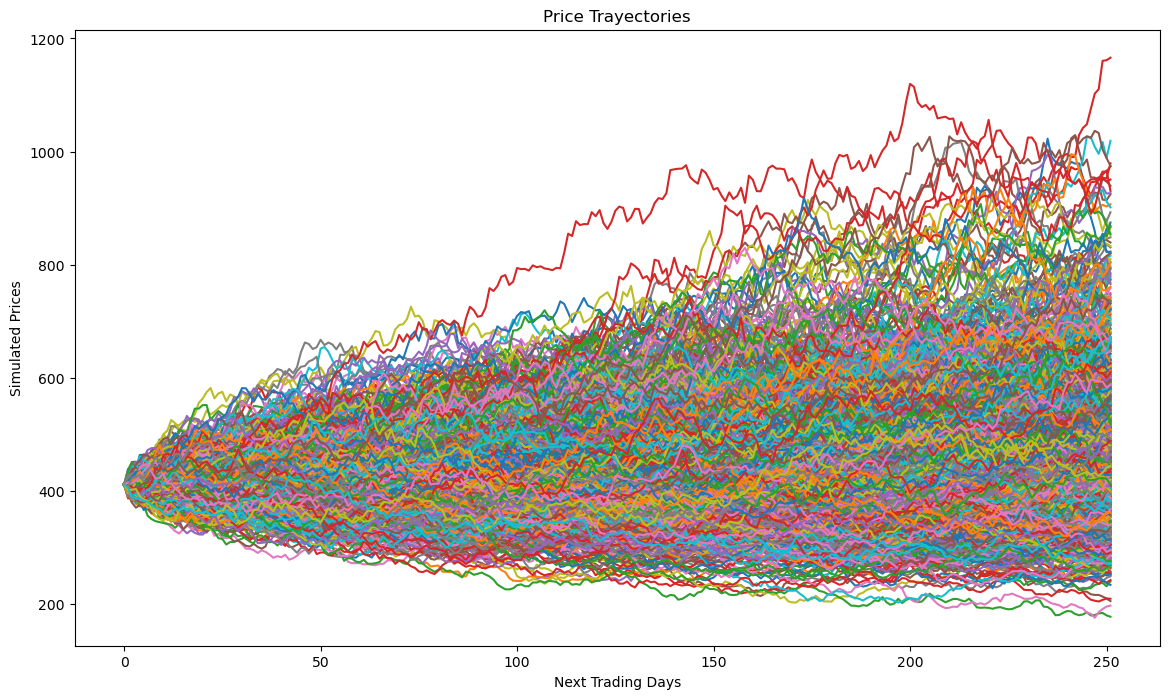

Here, we can see all 1000 simulations, the number of simulations and trading days predicted can be changed anytime simply changing the intervals and iterations variables.


In [8]:
#The plot is as follows
plt.figure(figsize = (14, 8))
plt.plot(sim_prices)
plt.xlabel("Next Trading Days")
plt.ylabel("Simulated Prices")
plt.title("Price Trayectories")
plt.show()
print("Here, we can see all 1000 simulations, the number of simulations and trading days predicted can be changed anytime simply changing the intervals and iterations variables.")

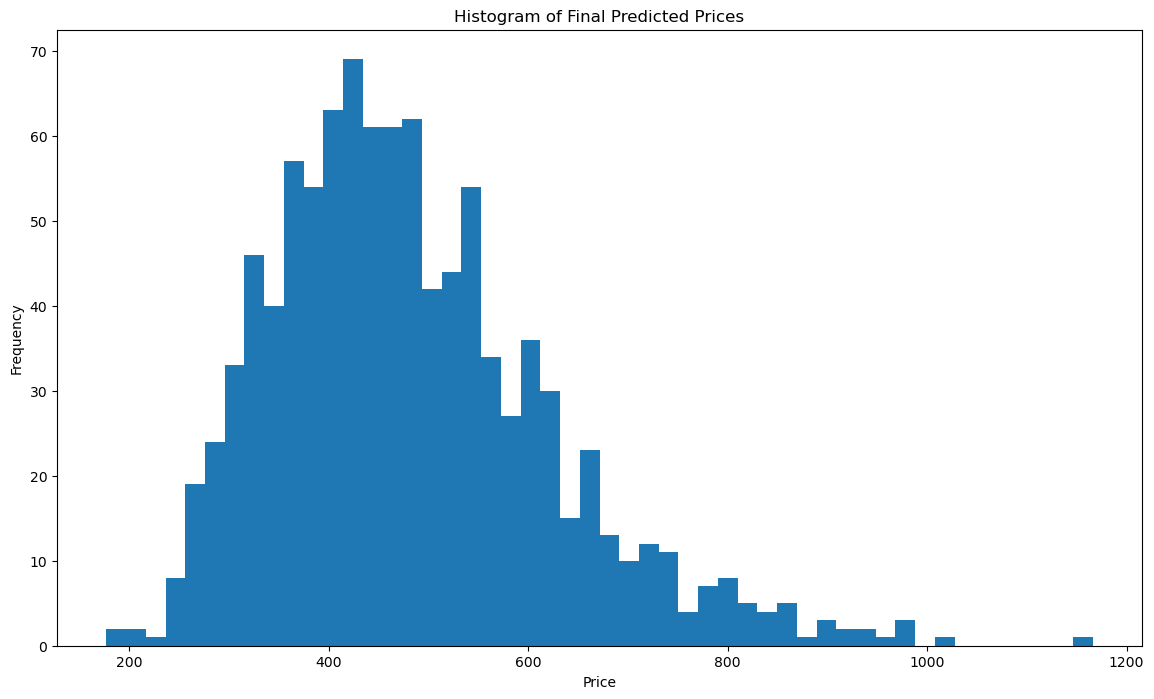

The 5% lower probability (worst case scenario) is that the price reaches a price of: 290.89083250288627 
The most likely price (50th percentile) is: 461.42739250606354 
The top 5% probability (best case scenario) is that the price reaches: 741.3441581284266


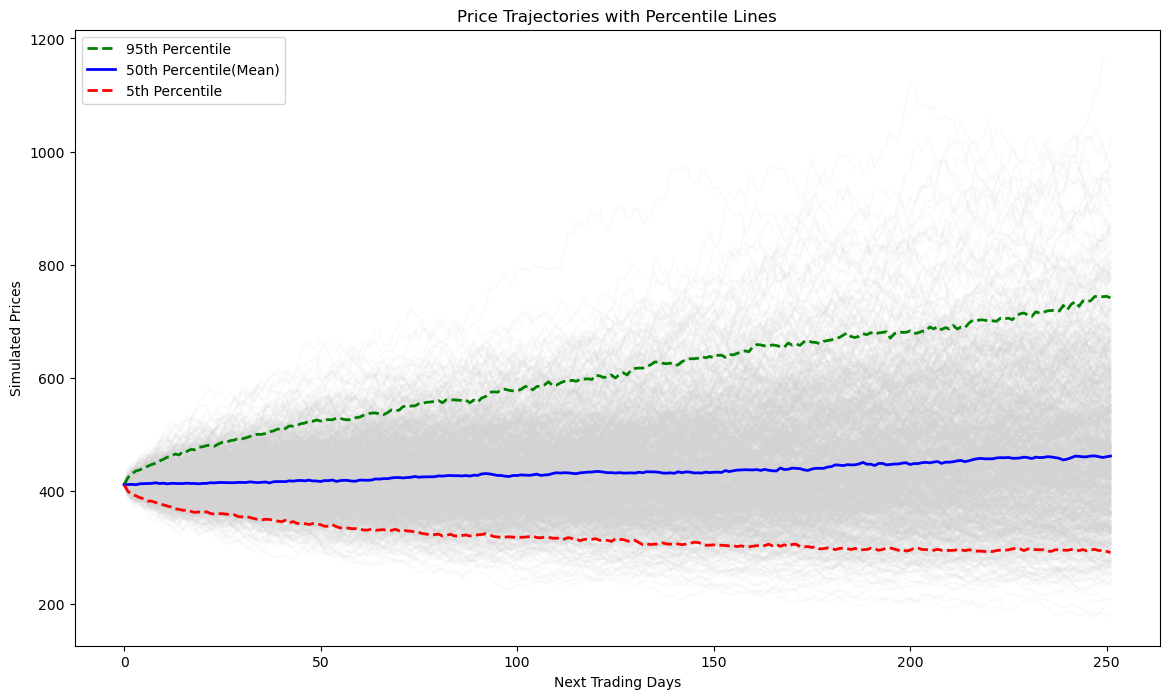

In [9]:
#Now the last predicted price for every simulation is extracted to create a histogram and see the most likely outcomes
import scipy.stats as stats
last_sim_prices = sim_prices[-1]
plt.figure(figsize = (14, 8))
plt.hist(last_sim_prices, bins = 50)
plt.title("Histogram of Final Predicted Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

#Now the percentiles are obtaind
p5 = np.percentile(sim_prices, 5, axis=1) 
p50 = np.percentile(sim_prices, 50, axis=1) 
p95 = np.percentile(sim_prices, 95, axis=1)
print("The 5% lower probability (worst case scenario) is that the price reaches a price of:", p5[-1], "\nThe most likely price (50th percentile) is:", p50[-1], "\nThe top 5% probability (best case scenario) is that the price reaches:", p95[-1])

#Now these percentiles lines are plotted in the same format as the simulated prices where.
plt.figure(figsize=(14, 8))
plt.plot(sim_prices, color='lightgray', alpha=0.1) 

# Plot the thick percentile lines over the top
plt.plot(p95, color='green', linestyle='--', linewidth=2, label='95th Percentile')
plt.plot(p50, color='blue', linestyle='-', linewidth=2, label='50th Percentile(Mean)')
plt.plot(p5, color='red', linestyle='--', linewidth=2, label='5th Percentile')
plt.title("Price Trajectories with Percentile Lines")
plt.xlabel("Next Trading Days")
plt.ylabel("Simulated Prices")
plt.legend()
plt.show()

In [10]:
#Final calculations and interpretation
exp_final_price = sim_prices[-1].mean()
print("The expected value (mean) is:", round(exp_final_price, 3))
print("We can see that this mean is different from the 50th percentile", round(p50[-1], 3), "\nThis is because the mean takes the extreme outliers into account while the 50th percentile(median) doesn't, and only gives us the value in the middle.")
print("This is why the median is considered a more realistic expectation. The most likely price to be hit in one year is:", round(p50[-1], 3))

#The round() method is used in the variables to only show 3 decimals
#Now the probability of loss is calculated
loss_cases = last_sim_prices < S0 #Boolean matrix with either true for lower price than starting and false for higher
prob_of_loss = loss_cases.mean() #Mean of a boolean matrix returns the percentage of times there is True
print("The estimated probability of losig money is:", round(prob_of_loss * 100, 3), "%")

#Finally, the estimated probability of losing more than 10% of our money in the same way, but comparing it to a lower number (10%)
ten_percent_loss = S0 * 0.90
ten_percent_loss_cases = last_sim_prices < ten_percent_loss
prob_of_ten_percent_loss = ten_percent_loss_cases.mean()
print("The estimated probability of losing more than 10% is of:", round(prob_of_ten_percent_loss * 100, 3), "%")

half_loss = S0 * 0.50
half_loss_cases = last_sim_prices < half_loss
prob_of_half_loss = half_loss_cases.mean()
print("The estimated probability of losing half of the money is of:", round(prob_of_half_loss * 100, 3), "%")

double_money = S0 * 2
double_money_cases = last_sim_prices > double_money
prob_of_double_money = double_money_cases.mean()
print("The estimated probability of doubling our money is of:", round(prob_of_double_money * 100, 3), "%")

The expected value (mean) is: 481.905
We can see that this mean is different from the 50th percentile 461.427 
This is because the mean takes the extreme outliers into account while the 50th percentile(median) doesn't, and only gives us the value in the middle.
This is why the median is considered a more realistic expectation. The most likely price to be hit in one year is: 461.427
The estimated probability of losig money is: 34.0 %
The estimated probability of losing more than 10% is of: 21.8 %
The estimated probability of losing half of the money is of: 0.3 %
The estimated probability of doubling our money is of: 2.5 %


NOTE: Since markdown doesn't allow variable inputs the following numbers in the conclusion are for one simulation, but it will vary when the code is run again. However, the numbers should be similar and the conclusions won't change.

***CONCLUSIONS***  
With this MonteCarlo simulation we made an analysis on the future of the price of tech company stock MICROSOFT. As the moment of the making of this project, the price of the stock sits at 410.67$. We have discovered that the probabilty of success of investing in this company is quite high (66%). The risk of losing money is not very low, however the amount lost would be small, as the probability of losing only 10% of our money decreases to 21.8% and the probability of losing half our money (a very bad investment) is of only 0.3%. We also find out that the probability of doubling our money (great investment) is of only 2.5%, this would be a profit of 100%. According to the past data gathered (5 years) we conclude that microsoft is a good investment, with decent probable returns and low risk. In order to perfect this analysis we could make the following more advanced improvements in the future:  
- Incorporate "fat tails": This analysis asumes a normal dsitribution for the daily stock returns, but in reality, extreme events happen (fat tails in the distribution) more often than a normal bell curve predicts.  
- Incorporate dynamic volatility: It is assumed that the volatility througout the year reamins constant, but this is not the case as volatility comes in waves.
- Get more data: 5 years might not be enough data for a rigorous analysis. We could try to get 10 or 15 years. This is a very simple change.